In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

Explicação do das variáveis:
* distancefromhome - a distância de casa onde a transação aconteceu.
* distancefromlast_transaction - a distância da última transação aconteceu.
* ratiotomedianpurchaseprice - Razão da transação do preço de compra para o preço de compra mediano.
* repeat_retailer - É a transação que aconteceu do mesmo varejista.
* used_chip - É a transação através de chip (cartão de crédito).
* usedpinnumber - A transação aconteceu usando o número PIN.
* online_order - A transação é um pedido online.
* fraude - A transação é fraudulenta.

In [2]:
url_transdata = "https://raw.githubusercontent.com/FIAP/Pos_Tech_DTAT/refs/heads/main/Fase%202/02%20-%20Machine%20Learning%20Avan%C3%A7ado/Aula%202/Base%20de%20Dados/card_transdata.csv"

In [3]:
card = pd.read_csv(url_transdata)
card.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


In [4]:
card.shape

(1000000, 8)

In [5]:
card.isnull().sum()

,0
distance_from_home,0
distance_from_last_transaction,0
ratio_to_median_purchase_price,0
repeat_retailer,0
used_chip,0
used_pin_number,0
online_order,0
fraud,0


In [6]:
card.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
card[card["fraud"] == 1].fraud.count()

np.int64(87403)

In [8]:
total = len(card)
totalnaofraudes = card[card["fraud"] == 0].fraud.count()
totalfraudes = card[card["fraud"] == 1].fraud.count()
percentual_fraudes = totalfraudes / total
print("Total de dados: ", total)
print("Total de não fraudes: ", totalnaofraudes)
print("Total de fraudes: ", totalfraudes)
print("Percentual de fraudes na base: ", (round(percentual_fraudes, 2)*100), "%")

Total de dados:  1000000
Total de não fraudes:  912597
Total de fraudes:  87403
Percentual de fraudes na base:  9.0 %


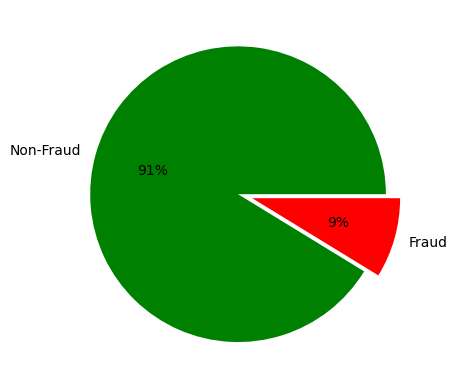

In [9]:
categorias = ["Non-Fraud","Fraud"]
plt.pie(card["fraud"].value_counts(),labels=categorias, autopct = "%.0f%%", explode= (0, 0.1), colors = ("g", "r"))
plt.show()

In [10]:
dados_fraudes = card[card["fraud"]==1]
dados_fraudes.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
13,2.131956,56.372401,6.358667,1.0,0.0,0.0,1.0,1.0
24,3.803057,67.241081,1.872950,1.0,0.0,0.0,1.0,1.0
29,15.694986,175.989182,0.855623,1.0,0.0,0.0,1.0,1.0
35,26.711462,1.552008,4.603601,1.0,1.0,0.0,1.0,1.0
36,10.664474,1.565769,4.886521,1.0,0.0,0.0,1.0,1.0


In [11]:
dados_fraudes.describe().T

,count,mean,std,min,25%,50%,75%,max
distance_from_home,87403.0,66.261876,134.391608,0.025847,4.585729,15.454219,101.110104,10632.723672
distance_from_last_transaction,87403.0,12.712185,47.997697,0.000407,0.328199,1.157631,4.598504,2160.499922
ratio_to_median_purchase_price,87403.0,6.006323,5.564320,0.011966,3.500270,5.071294,7.331222,266.689692
repeat_retailer,87403.0,0.880119,0.324825,0.000000,1.000000,1.000000,1.000000,1.000000
used_chip,87403.0,0.256399,0.436647,0.000000,0.000000,0.000000,1.000000,1.000000
used_pin_number,87403.0,0.003123,0.055801,0.000000,0.000000,0.000000,0.000000,1.000000
online_order,87403.0,0.946318,0.225391,0.000000,1.000000,1.000000,1.000000,1.000000
fraud,87403.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


<Axes: xlabel='online_order', ylabel='count'>

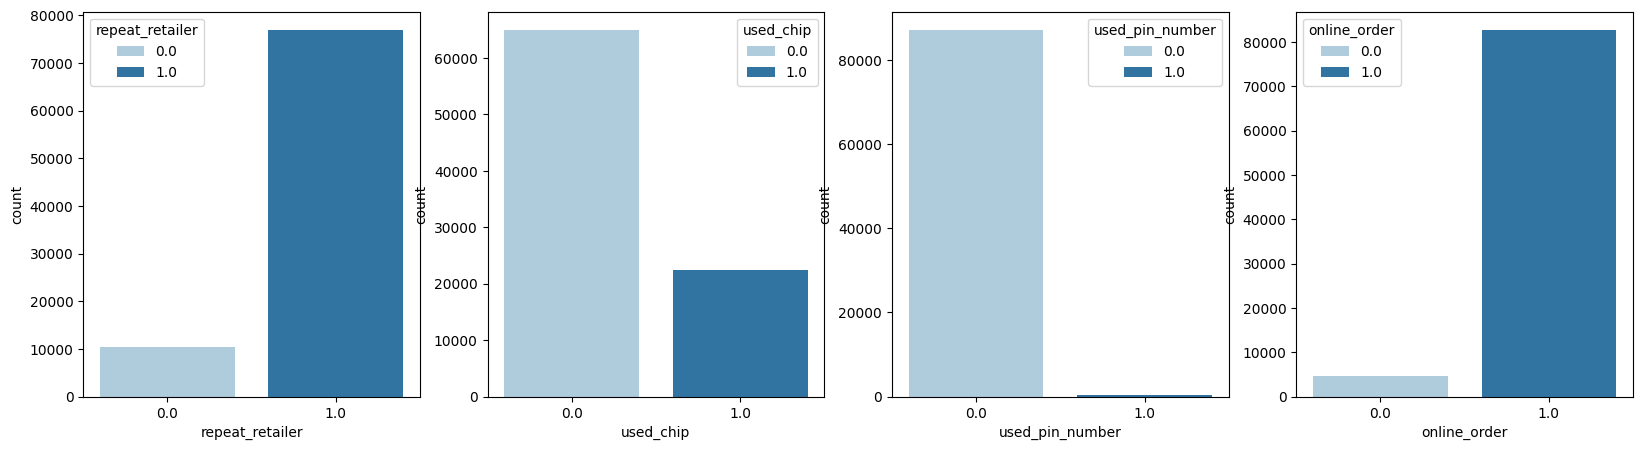

In [12]:
plt.figure(figsize = (20,5)) #Configurando o tamanho da visualização

plt.subplot(1,4,1)
sns.countplot(x = "repeat_retailer", palette = "Paired", data = dados_fraudes,hue="repeat_retailer") #Aconteceu no mesmo varejista?

plt.subplot(1,4,2)
sns.countplot(x = "used_chip", palette = "Paired", data = dados_fraudes,hue="used_chip") #Uso de cartão de crédito?

plt.subplot(1,4,3)
sns.countplot(x = "used_pin_number", palette = "Paired", data = dados_fraudes,hue="used_pin_number") #Utilizou o mesmo número de PIN?

plt.subplot(1,4,4)
sns.countplot(x = "online_order", palette = "Paired", data = dados_fraudes,hue="online_order") #Foi em uma compra online?

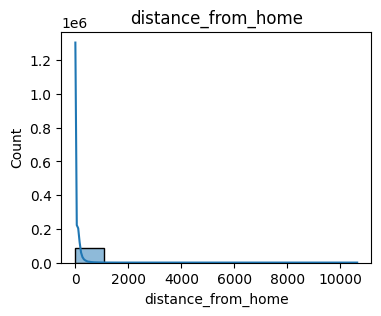

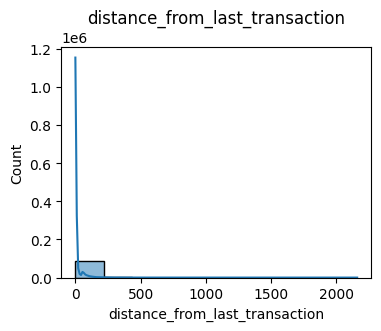

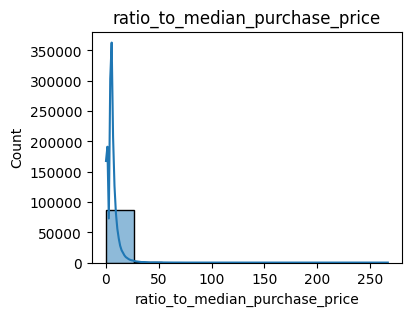

In [13]:
colunas_Numericas = ["distance_from_home","distance_from_last_transaction","ratio_to_median_purchase_price"]

for column in colunas_Numericas:
    plt.figure(figsize=(4, 3))  # largura x altura (em polegadas)
    sns.histplot(dados_fraudes[column], bins=10, kde=True)
    plt.title(column)
    plt.show()

In [14]:
for column in [0, 1, 2]:
    dados_fraudes.iloc[:, column] = np.log10(dados_fraudes.iloc[:, column]) #transformação logarítma

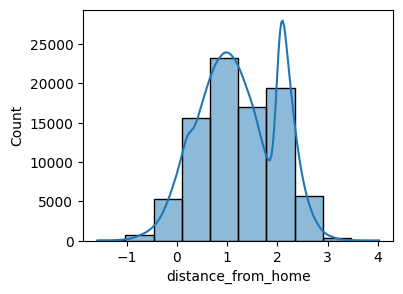

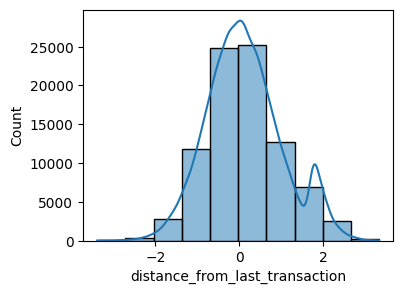

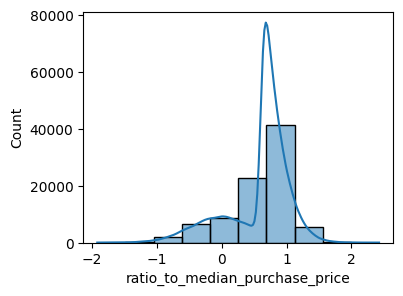

In [15]:
colunas_Numericas_Normal = ["distance_from_home", "distance_from_last_transaction", "ratio_to_median_purchase_price"]
for column in colunas_Numericas_Normal:
    plt.figure(figsize=(4, 3))
    plot = dados_fraudes[column]
    sns.histplot(plot, bins=10, kde=True)
    plt.show()

In [16]:
round(dados_fraudes.distance_from_last_transaction.mean(),2)

np.float64(0.13)

In [17]:
round(dados_fraudes.distance_from_last_transaction.std(),2)

0.9

In [19]:
card.head()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0


<Axes: >

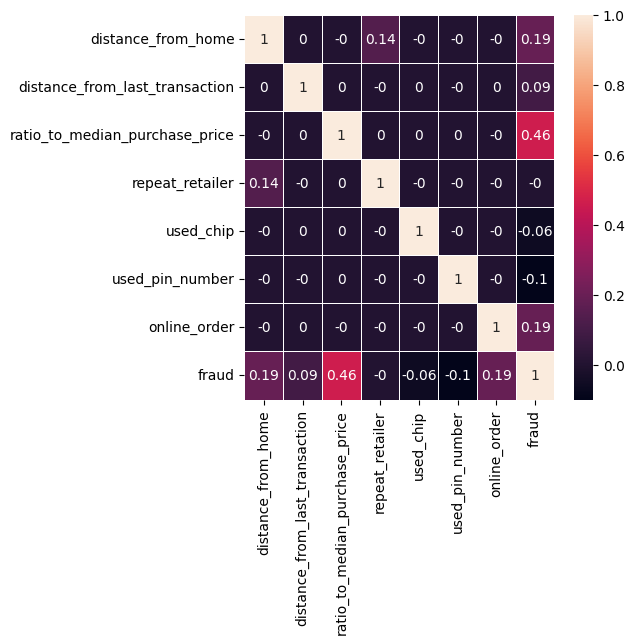

In [21]:
correlation_matrix = card.corr().round(2)

fig, ax = plt.subplots(figsize=(5,5))
sns.heatmap(data=correlation_matrix, annot=True, linewidths=.5, ax=ax)

In [22]:
x = card[['distance_from_home','ratio_to_median_purchase_price', 'online_order']]
y = card['fraud'] #target

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y,random_state=7) #20% para teste e 80% de treino

Feature Engineer
Comparação da escala normal das variáveis vs. escalonamento das variáveis

* Comparação do real x dados transformado (normalização e padronização)
padronização: zera a média e deixa o desvio padrão unitário.( obteremos desvios-padrão menores por meio do processo de normalização minmaxscaler).
* Normalização: coloca a variável na escala entre 0 até 1.
* Análise da plotagem real e verificar se está muito diferente da plotagem com standerscaler e minmaxsclaer.
* Escolha o tipo de transformação de escala que melhor se adequa a suas variáveis. Se o desenho do gráfico mudar, você está descaracterizando o dado.

In [24]:
#scaler = StandardScaler()
scaler = MinMaxScaler()
scaler.fit(x_train)

MinMaxScaler()

In [25]:
# Na hora de transformar, devemos transformar ambos os conjuntos
x_train_escalonado = scaler.transform(x_train)#treino
x_test_escalonado = scaler.transform(x_test)#teste

In [26]:
x_train

,distance_from_home,ratio_to_median_purchase_price,online_order
459304,47.575388,0.992054,0.0
913193,28.754925,5.108844,1.0
278587,3.124923,2.124761,1.0
521682,21.042733,1.545996,1.0
293018,6.354463,0.320672,1.0
...,...,...,...
871097,10.965039,4.241274,1.0
932655,8.551129,0.700205,1.0
430609,3.765416,1.960024,0.0
246177,5.609825,23.143594,0.0


In [27]:
x_train_escalonado

array([[4.47397457e-03, 3.68805271e-03, 0.00000000e+00],
       [2.70392280e-03, 1.90607654e-02, 1.00000000e+00],
       [2.93438485e-04, 7.91775122e-03, 1.00000000e+00],
       ...,
       [3.53676362e-04, 7.30259599e-03, 0.00000000e+00],
       [5.27141795e-04, 8.64052299e-02, 0.00000000e+00],
       [9.41482438e-04, 3.40812710e-02, 0.00000000e+00]])

In [28]:
error = []

# Calculating error for K values between 1 and 10
for i in range(1, 10): #range de tentativas para k
    knn = KNeighborsClassifier(n_neighbors=i)# aqui definimos  o k
    knn.fit(x_train_escalonado, y_train) #treinando o algoritmo para encontrar o erro
    pred_i = knn.predict(x_test_escalonado) #armazenando as previsões
    error.append(np.mean(pred_i != y_test)) #armazenando o valor do erro médio na lista de erros

Text(0, 0.5, 'Mean Error')

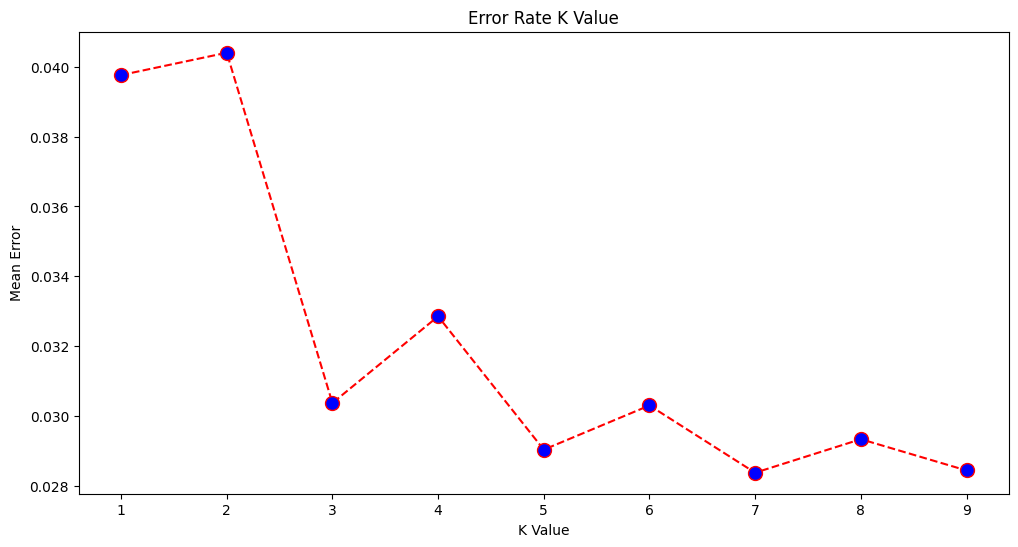

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 10), error, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [30]:
modelo_classificador = KNeighborsClassifier(n_neighbors=7)

In [32]:
modelo_classificador.fit(x_train_escalonado, y_train)

KNeighborsClassifier(n_neighbors=7)

In [33]:
y_predito = modelo_classificador.predict(x_test_escalonado) #defininfo as predições

In [34]:
#print('Training set score: {:.4f}'.format(modelo_classificador.score(x_train, y_train)))
#print('Test set score: {:.4f}'.format(modelo_classificador.score(x_test, y_test)))

In [35]:
# Acurácia do modelo
print(accuracy_score(y_test, y_predito))

0.97162
